In [ ]:
%env CUDA_VISIBLE_DEVICES=0

In [1]:
import torch; print(torch.version.cuda); print(torch.cuda.is_available())


11.8
True


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import torch

%matplotlib inline

In [41]:
use_cuda = torch.cuda.is_available()
device = 'cuda' if use_cuda else 'cpu'

#Do not forget to run pip install facenet-pytorch
from facenet_pytorch import MTCNN
mtcnn = MTCNN(keep_all=False, post_process=False, min_face_size=15, device=device)

def detect_face(frame):
    bounding_boxes, probs = mtcnn.detect(frame, landmarks=False)
    bounding_boxes=bounding_boxes[probs>0]
    return bounding_boxes

print(use_cuda)

True


In [42]:
from hsemotion.facial_emotions import HSEmotionRecognizer
model_name='enet_b0_8_best_afew'
#model_name='enet_b0_8_best_vgaf'
#model_name='enet_b0_8_va_mtl'
#model_name='enet_b2_8'

fer=HSEmotionRecognizer(model_name=model_name,device=device)

/home/uros/.hsemotion/enet_b0_8_best_afew.pt Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=warn)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


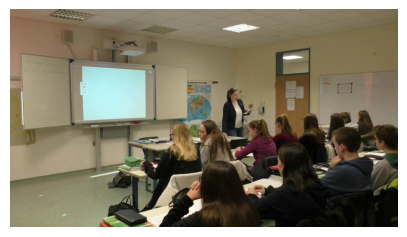

In [43]:
fpath='/home/uros/Documents/project31/programming/NI_clean/data/inputs/first_frames/00155.png'
frame_bgr = cv2.imread(fpath)
plt.figure(figsize=(5, 5))
frame = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
plt.axis('off')
plt.imshow(frame)

bounding_boxes=detect_face(frame)

In [44]:
bounding_boxes

array([[1060.5279541015625, 424.94061279296875, 1097.2208251953125,
        492.76953125],
       [1198.996337890625, 416.8610534667969, 1233.70751953125,
        470.0942077636719],
       [622.5203857421875, 385.8428039550781, 653.1787719726562,
        438.0814514160156],
       [783.3770751953125, 384.14117431640625, 809.78759765625,
        427.2333984375],
       [731.8619995117188, 272.4415588378906, 753.5127563476562,
        302.9115295410156]], dtype=object)

Surprise [1.623241   0.37490368 1.7501765  1.4904798  0.74187654 2.227427
 1.1465149  2.5807955 ]
Neutral [2.1304443 0.5539272 1.5933994 2.3410332 1.7297446 2.5861366 1.6187726
 2.3193038]
Neutral [ 2.0740514  -0.98351765 -0.5964027  -0.00791659 -0.38321447  2.9975889
  1.76017     0.83523774]
Neutral [1.3460121  0.35308188 0.95482844 0.89212567 1.8823851  2.858844
 0.75612974 1.775815  ]
Neutral [ 0.77450216  0.03824123 -0.06530659  1.8849517   2.3398166   2.6022327
  1.3737061   0.71200526]


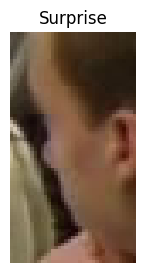

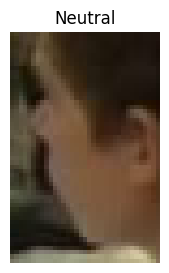

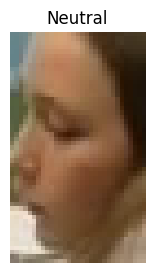

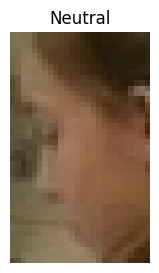

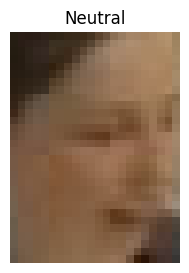

In [45]:
for bbox in bounding_boxes:
    box = bbox.astype(int)
    x1,y1,x2,y2=box[0:4]    
    face_img=frame[y1:y2,x1:x2,:]
    emotion,scores=fer.predict_emotions(face_img,logits=True)
    print(emotion,scores)
    
    plt.figure(figsize=(3, 3))
    plt.axis('off')
    plt.imshow(face_img)
    plt.title(emotion)

In [18]:
features=fer.extract_features(face_img)
print(features.shape,features)

(1, 1280) [[-0.02719006 -0.10372426 -0.15168738 ...  0.24768206 -0.19170406
  -0.00187532]]


['Neutral', 'Neutral', 'Neutral', 'Neutral', 'Neutral'] [[0.0261755  0.07088857 0.01645748 0.01627452 0.10018627 0.5540605
  0.19107972 0.02487744]
 [0.10778285 0.02751189 0.00285688 0.00691125 0.02259536 0.63205636
  0.19327681 0.00700861]
 [0.05760802 0.06620093 0.05525401 0.09609397 0.18434447 0.28856987
  0.07354434 0.17838441]
 [0.01623493 0.00533766 0.00126769 0.00733173 0.1638437  0.56897545
  0.19894257 0.03806631]
 [0.0942556  0.01790629 0.02125548 0.03903078 0.08235732 0.5973726
  0.07192677 0.07589517]]


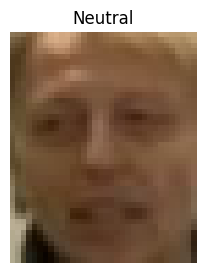

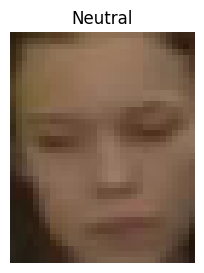

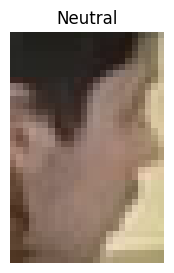

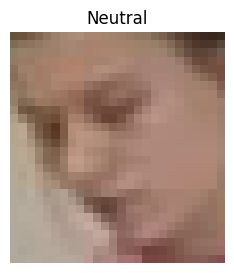

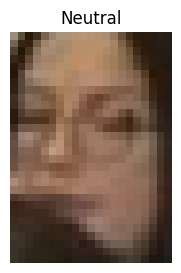

In [8]:
face_img_list=[]
for bbox in bounding_boxes:
    box = bbox.astype(int)
    x1,y1,x2,y2=box[0:4]    
    face_img=frame[y1:y2,x1:x2,:]
    face_img_list.append(face_img)

emotions,scores=fer.predict_multi_emotions(face_img_list,logits=False)
print(emotions,scores)

for face_img,emotion in zip(face_img_list,emotions):    
    plt.figure(figsize=(3, 3))
    plt.axis('off')
    plt.imshow(face_img)
    plt.title(emotion)

In [9]:
features=fer.extract_multi_features(face_img_list)
print(features.shape,features)

(5, 1280) [[-0.14328887 -0.0022674  -0.19953223 ... -0.01896827  0.06763909
   0.3119173 ]
 [-0.09271248 -0.11300984 -0.08138578 ...  0.10580175 -0.04122922
   0.25977775]
 [-0.10434654 -0.13951373 -0.02272382 ... -0.10798025 -0.24159198
  -0.14194863]
 [-0.03405094 -0.10005325 -0.14413217 ...  0.12214154  0.07946149
   0.27322155]
 [-0.11006135 -0.14229093 -0.09287141 ...  0.09841185  0.01230067
   0.11336558]]
